In [1]:
import sys
# For notebooks inside research/ftir_hips_chem/:
sys.path.insert(0, './scripts')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cross_decomposition import PLSRegression

# Config + data
from config import (
    SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH,
    AERONET_DATA_DIR, WEATHER_DATA_DIR, MAC_VALUE,
)

# Exclusions (the IMPROVE RDS cohort already carries its model exclusions; no new
# sample is silently removed here—eligibility and missing-reference rows are audited.)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
)
from etad_factors import load_etad_factor_contributions, match_etad_factors

# Plotting—importing applies the repository white-background default.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

from pls_transfer import (
    FTIRTransferPaths, load_current_pls_model, vip_scores,
    select_components_cv, nested_cv_predictions, regression_metrics,
    score_metric, project_scores, mahalanobis_distance_squared,
    pairwise_score_distance_squared, spectral_q_residual, offset_correct,
    vip_overlap_summary, summarize_vip_bands, spaced_peak_table,
)

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)
PATHS = FTIRTransferPaths.defaults()
TABLE_DIR = Path('output/tables/pls_transfer')
PLOT_DIR = Path('output/plots/pls_transfer')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Find IMPROVE analogs for Addis in HIPS-relevant PLS space and rebuild TOR EC

## tl;dr

The full lot-248/251 search screened **13,634 spectra** (13,632 unique filters), found **13,010** with
eligible TOR EC references, and selected **400 analogs spanning 120 sites**. The exploratory analog
TOR model improves Addis agreement with HIPS at MAC = 10: slope **1.32**, intercept **−1.64**, R²
**0.702**, and RMSE **1.02 µg m⁻³**, versus **2.30**, **−5.38**, **0.607**, and **2.70** for the current
model. Its RMSE is lower than all 10 size-matched random refits, and its R² exceeds their maximum
(0.693). The apparent improvement is MAC-sensitive: at MAC = 6, the analog model's RMSE is **3.49**
versus **3.15** for the current model.

## Context & Methods

This notebook searches all lot-248/251 IMPROVE spectra, not only smoke-classified days.
Similarity is evaluated three ways: score-space Mahalanobis distance in the IMPROVE HIPS
PLS model, residual spectral magnitude Q, and a baseline-offset-corrected VIP-weighted
spectral mismatch. The top analogs with TOR EC references are then used to build an
exploratory TOR calibration.

### Key Assumptions

- Mahalanobis distance and Q are applicability diagnostics, not proof of low prediction error.
- Analog selection is supervised by a HIPS model, so comparisons to HIPS are descriptive and
  not an independent validation of the selected TOR calibration.
- Offset correction in 3900–4000 cm⁻¹ is a sensitivity approximation; it is not a replacement
  for a fully validated AIRSpec EDF 6–8 processing run on all 13,000 spectra.

## Data and reference model

In [2]:
arrays = np.load(PATHS.ftir_dir / 'apps/apps_data.npz', allow_pickle=True)
wn = arrays['wn'].astype(float)
calibration_rows = pd.DataFrame({
    'row': np.arange(len(arrays['EC_id'])),
    'AnalysisId': arrays['EC_id'].astype(int),
    'FilterId': arrays['EC_fid'].astype(int),
    'Site': arrays['EC_site'].astype(str),
})
improve_hips_raw = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_hips.csv',
    usecols=['MatchedFilterId', 'Parameter', 'Value', 'AverageFlowRate',
             'ElapsedTime', 'SampleDepositArea'],
)
improve_hips = (improve_hips_raw[improve_hips_raw['Parameter'].str.casefold() == 'fabs']
                .drop_duplicates('MatchedFilterId'))
improve_join = calibration_rows.merge(
    improve_hips[['MatchedFilterId', 'Value', 'AverageFlowRate',
                  'ElapsedTime', 'SampleDepositArea']],
    left_on='FilterId', right_on='MatchedFilterId', how='left', validate='one_to_one')
improve_join['SampleVolume_m3'] = (
    improve_join['AverageFlowRate'] / 1000.0 * improve_join['ElapsedTime']
)
improve_join['HIPS_tau'] = (
    improve_join['Value'] * improve_join['SampleVolume_m3'] /
    (100.0 * improve_join['SampleDepositArea'])
)
eligible = (improve_join['Value'].notna() & improve_join['SampleVolume_m3'].gt(0) &
            improve_join['SampleDepositArea'].gt(0) & improve_join['HIPS_tau'].notna())
X_improve_hips = arrays['EC_X'][improve_join.loc[eligible, 'row'].to_numpy()].astype(float)
y_improve_fabs = improve_join.loc[eligible, 'Value'].to_numpy(float)
y_improve_hips = improve_join.loc[eligible, 'HIPS_tau'].to_numpy(float)
site_improve_hips = improve_join.loc[eligible, 'Site'].to_numpy()

In [3]:
# One spectrum per physical filter: average replicate scans before model fitting/CV.
raw_etad = pd.read_csv(PATHS.etad_dir / 'ETAD_FTIR_spectra.csv')
etad_meta = pd.read_csv(PATHS.etad_dir / 'ETAD_metadata.csv')
wcols = sorted([c for c in raw_etad.columns if c not in ('SampleAnalysisId', 'MediaId')],
               key=lambda value: -float(value))
assert np.allclose(np.array([float(c) for c in wcols]), wn)
etad_spectra = raw_etad.groupby('MediaId', as_index=False)[wcols].mean()

# The primary file is newer and has 239 ETAD HIPS results versus 190 in the user-listed backup.
hips_primary = pd.read_csv(PATHS.spartan_hips_primary, encoding='cp1252')
hips_backup = pd.read_csv(PATHS.spartan_hips_backup, encoding='cp1252')
hips_fields = ['FilterId', 'Fabs', 'tau', 'DepositArea', 'Volume']
primary_etad = hips_primary[hips_primary['Site'] == 'ETAD'][hips_fields].drop_duplicates('FilterId')
backup_etad = hips_backup[hips_backup['Site'] == 'ETAD'][hips_fields].drop_duplicates('FilterId')
source_compare = primary_etad.merge(backup_etad, on='FilterId', suffixes=('_primary', '_backup'))
source_audit = pd.DataFrame([{
    'primary_nonnull': int(primary_etad['Fabs'].notna().sum()),
    'backup_nonnull': int(backup_etad['Fabs'].notna().sum()),
    'overlap_n': int(source_compare[['Fabs_primary', 'Fabs_backup']].dropna().shape[0]),
    'overlap_max_abs_difference': float(np.nanmax(np.abs(source_compare['Fabs_primary'] - source_compare['Fabs_backup']))),
    'primary_tau_formula_max_abs_difference': float(np.nanmax(np.abs(
        primary_etad['Fabs'] * primary_etad['Volume'] /
        (100.0 * primary_etad['DepositArea']) - primary_etad['tau']))),
}])

etad = (etad_spectra.merge(etad_meta, on='MediaId', how='left')
        .merge(primary_etad.rename(columns={'FilterId': 'ExternalFilterId'}),
               on='ExternalFilterId', how='left'))
etad['has_spectrum'] = etad[wcols].notna().all(axis=1)
etad['has_hips'] = etad['Fabs'].notna()
etad['positive_volume'] = etad['SampleVolume_m3'].gt(0)
etad['positive_deposit_area'] = etad['DepositArea'].gt(0)
etad_eval = etad[etad['has_spectrum'] & etad['has_hips'] & etad['positive_volume'] & etad['positive_deposit_area']].copy()
etad_eval['HIPS_tau'] = (
    etad_eval['Fabs'] * etad_eval['SampleVolume_m3'] / (100.0 * etad_eval['DepositArea'])
)
X_etad = etad_eval[wcols].to_numpy(float)
y_etad = etad_eval['Fabs'].to_numpy(float)
y_etad_tau = etad_eval['HIPS_tau'].to_numpy(float)

In [4]:
improve_k, improve_curve = select_components_cv(
    X_improve_hips, y_improve_hips, range(1, 26),
    groups=site_improve_hips, n_splits=5, random_state=42)
improve_model = PLSRegression(n_components=improve_k, scale=False).fit(X_improve_hips, y_improve_hips)
improve_vip = vip_scores(improve_model)
calibration_scores, inverse_score_ss = score_metric(improve_model)
etad_scores = project_scores(improve_model, X_etad)
etad_score_center = np.median(etad_scores, axis=0)
etad_spectrum_target = np.nanmedian(offset_correct(X_etad, wn), axis=0)
vip_weights = improve_vip**2 / np.sum(improve_vip**2)
print(f'IMPROVE HIPS model: n={len(y_improve_hips)}, k={improve_k}; Addis evaluation n={len(etad_eval)}')

IMPROVE HIPS model: n=916, k=1; Addis evaluation n=239


## Results

### 1. Screen the complete 13k lot-matched pool in bounded chunks

In [5]:
pool_path = PATHS.ftir_dir / 'local_db/spectra_248_251.csv'
metadata_cols = ['AnalysisId', 'FilterId', 'SampleDate', 'Site']
pool_parts = []
for chunk_number, chunk in enumerate(pd.read_csv(pool_path, chunksize=750), start=1):
    X_chunk = chunk[wcols].to_numpy(float)
    scores = project_scores(improve_model, X_chunk)
    q = spectral_q_residual(improve_model, X_chunk)
    d_center = pairwise_score_distance_squared(scores, etad_score_center, inverse_score_ss)
    corrected = offset_correct(X_chunk, wn)
    vip_rmse = np.sqrt(((corrected - etad_spectrum_target) ** 2) @ vip_weights)
    part = chunk[metadata_cols].copy()
    for component in range(scores.shape[1]):
        part[f'score_{component + 1}'] = scores[:, component]
    part['D2_to_Addis_centroid'] = d_center
    part['Q_residual'] = q
    part['VIP_weighted_spectral_RMSE'] = vip_rmse
    pool_parts.append(part)
pool = pd.concat(pool_parts, ignore_index=True)

score_columns = [f'score_{component + 1}' for component in range(improve_k)]
pool_scores = pool[score_columns].to_numpy(float)
# Whiten with the calibration score metric, then find each pool sample's nearest Addis filter.
metric_root = np.linalg.cholesky(inverse_score_ss)
nearest = cdist(pool_scores @ metric_root, etad_scores @ metric_root,
                metric='sqeuclidean').min(axis=1)
pool['D2_to_nearest_Addis'] = nearest
pool['D2_leverage'] = mahalanobis_distance_squared(pool_scores, inverse_score_ss)
pool['analog_rank_score'] = (
    pool['D2_to_nearest_Addis'].rank(pct=True) +
    pool['VIP_weighted_spectral_RMSE'].rank(pct=True)
) / 2
pool.to_csv(TABLE_DIR / 'improve_full_pool_addis_similarity.csv', index=False)
print(f'Full pool screened: {len(pool):,} spectra; unique filters={pool.FilterId.nunique():,}')
display(pool.nsmallest(10, 'analog_rank_score')[metadata_cols + [
    'D2_to_nearest_Addis', 'Q_residual', 'VIP_weighted_spectral_RMSE', 'analog_rank_score']])

Full pool screened: 13,634 spectra; unique filters=13,632


,AnalysisId,FilterId,SampleDate,Site,D2_to_nearest_Addis,Q_residual,VIP_weighted_spectral_RMSE,analog_rank_score
9103,164013,2003410,11/10/2022 12:00:00 AM,BRIS1,1.518551e-14,0.735401,0.008492,0.003777
12333,167686,2032928,3/10/2023 12:00:00 AM,PORE1,1.495504e-13,0.823574,0.008464,0.004401
8975,162999,2001558,11/4/2022 12:00:00 AM,OKEF1,6.587088e-13,0.837864,0.009279,0.007518
4757,157992,1982711,8/6/2022 12:00:00 AM,COHU1,8.216785e-13,0.819395,0.009339,0.008178
3806,156942,1979976,7/28/2022 12:00:00 AM,WHPA1,6.429681e-13,0.954821,0.009689,0.008545
7555,161067,1996844,10/14/2022 12:00:00 AM,COHU1,2.613066e-13,0.466413,0.009969,0.008692
5011,158259,1981861,8/9/2022 12:00:00 AM,GRSM1,1.805334e-12,0.677016,0.009148,0.009058
3407,156503,1979365,7/13/2022 12:00:00 AM,LOND1,1.013585e-13,0.938488,0.010313,0.009242
5258,158513,1981828,8/3/2022 12:00:00 AM,YELL2,3.762324e-12,0.670784,0.008804,0.009975
5924,159249,1989434,9/11/2022 12:00:00 AM,PACK1,1.871314e-12,0.377256,0.009504,0.010158


### 2. Restrict only by explicit TOR-reference eligibility, then select the closest analogs

In [6]:
tor = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
    usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'],
)
tor_ec = tor[tor['Parameter'] == 'EC'].copy()
tor_ec['date'] = pd.to_datetime(tor_ec['SampleDate'], errors='coerce').dt.normalize()
tor_ec = tor_ec.drop_duplicates(['Site', 'date'])
tor_ec['TOR_EC_loading_ug'] = (
    tor_ec['Value'] * (tor_ec['AverageFlowRate'] / 1000 * tor_ec['ElapsedTime']) / 1000
)
candidate_pool = pool.copy()
candidate_pool['date'] = pd.to_datetime(candidate_pool['SampleDate'], errors='coerce').dt.normalize()
candidate_pool = candidate_pool.merge(
    tor_ec[['Site', 'date', 'TOR_EC_loading_ug']],
    on=['Site', 'date'], how='left', validate='many_to_one')
candidate_pool['eligible_TOR_reference'] = candidate_pool['TOR_EC_loading_ug'].gt(0)
eligible_candidates = (candidate_pool[candidate_pool['eligible_TOR_reference']]
                       .sort_values('analog_rank_score')
                       .drop_duplicates('FilterId'))
N_ANALOGS = min(400, len(eligible_candidates))
analogs = eligible_candidates.head(N_ANALOGS).copy()
analogs['analog_rank'] = np.arange(1, len(analogs) + 1)
analogs.to_csv(TABLE_DIR / 'selected_improve_addis_analogs.csv', index=False)

# Size-matched random cohorts quantify whether analog selection adds value beyond
# simply refitting on any 400 lot-matched TOR samples.
RANDOM_REPEATS = 10
random_cohorts = []
for repeat in range(RANDOM_REPEATS):
    cohort = eligible_candidates.sample(N_ANALOGS, random_state=1000 + repeat).copy()
    cohort['random_repeat'] = repeat + 1
    random_cohorts.append(cohort)
random_cohort_index = pd.concat(random_cohorts, ignore_index=True)
random_cohort_index[['random_repeat', 'AnalysisId', 'FilterId']].to_csv(
    TABLE_DIR / 'random_size_matched_cohort_index.csv', index=False)

audit = pd.DataFrame([{
    'full_pool_spectra': len(pool),
    'full_pool_unique_filters': pool['FilterId'].nunique(),
    'TOR_eligible_unique_filters': eligible_candidates['FilterId'].nunique(),
    'selected_analogs': len(analogs),
    'selection_rule': 'mean percentile rank of nearest-Addis D2 and VIP-weighted RMSE',
}])
audit.to_csv(TABLE_DIR / 'analog_selection_audit.csv', index=False)
display(audit)
display(analogs[['analog_rank', 'AnalysisId', 'FilterId', 'Site', 'SampleDate',
                 'TOR_EC_loading_ug', 'D2_to_nearest_Addis',
                 'VIP_weighted_spectral_RMSE']].head(20))

calibration_d2 = mahalanobis_distance_squared(calibration_scores, inverse_score_ss)
etad_d2 = mahalanobis_distance_squared(etad_scores, inverse_score_ss)
calibration_q = spectral_q_residual(improve_model, X_improve_hips)
etad_q = spectral_q_residual(improve_model, X_etad)
domain_rows = []
for cohort, d2_values, q_values in [
    ('IMPROVE HIPS calibration', calibration_d2, calibration_q),
    ('Addis', etad_d2, etad_q),
    ('Full lot-248/251 pool', pool['D2_leverage'].to_numpy(), pool['Q_residual'].to_numpy()),
    ('Selected analogs', analogs['D2_leverage'].to_numpy(), analogs['Q_residual'].to_numpy()),
]:
    domain_rows.append({
        'cohort': cohort, 'n': len(d2_values),
        'D2_median': float(np.median(d2_values)), 'D2_p95': float(np.percentile(d2_values, 95)),
        'Q_median': float(np.median(q_values)), 'Q_p95': float(np.percentile(q_values, 95)),
    })
domain_summary = pd.DataFrame(domain_rows)
domain_summary.to_csv(TABLE_DIR / 'score_and_q_domain_summary.csv', index=False)
display(domain_summary)

/var/folders/mm/_3mrh2jn44v0tbpmmpqc1jq80000gn/T/ipykernel_10141/442563989.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tor_ec['date'] = pd.to_datetime(tor_ec['SampleDate'], errors='coerce').dt.normalize()
/var/folders/mm/_3mrh2jn44v0tbpmmpqc1jq80000gn/T/ipykernel_10141/442563989.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  candidate_pool['date'] = pd.to_datetime(candidate_pool['SampleDate'], errors='coerce').dt.normalize()


,full_pool_spectra,full_pool_unique_filters,TOR_eligible_unique_filters,selected_analogs,selection_rule
0,13634,13632,13010,400,mean percentile rank of nearest-Addis D2 and V...


,analog_rank,AnalysisId,FilterId,Site,SampleDate,TOR_EC_loading_ug,D2_to_nearest_Addis,VIP_weighted_spectral_RMSE
9103,1,164013,2003410,BRIS1,11/10/2022 12:00:00 AM,12.461081,1.518551e-14,0.008492
12333,2,167686,2032928,PORE1,3/10/2023 12:00:00 AM,0.042900,1.495504e-13,0.008464
8975,3,162999,2001558,OKEF1,11/4/2022 12:00:00 AM,10.516065,6.587088e-13,0.009279
4757,4,157992,1982711,COHU1,8/6/2022 12:00:00 AM,3.933382,8.216785e-13,0.009339
3806,5,156942,1979976,WHPA1,7/28/2022 12:00:00 AM,3.301161,6.429681e-13,0.009689
7555,6,161067,1996844,COHU1,10/14/2022 12:00:00 AM,5.899159,2.613066e-13,0.009969
5011,7,158259,1981861,GRSM1,8/9/2022 12:00:00 AM,6.799658,1.805334e-12,0.009148
3407,8,156503,1979365,LOND1,7/13/2022 12:00:00 AM,8.072890,1.013585e-13,0.010313
5258,9,158513,1981828,YELL2,8/3/2022 12:00:00 AM,6.463587,3.762324e-12,0.008804
5924,10,159249,1989434,PACK1,9/11/2022 12:00:00 AM,10.451871,1.871314e-12,0.009504


,cohort,n,D2_median,D2_p95,Q_median,Q_p95
0,IMPROVE HIPS calibration,916,0.000085,0.000952,0.992345,7.853699
1,Addis,239,0.000082,0.000542,1.134678,3.446715
2,Full lot-248/251 pool,13634,0.000385,0.000927,2.772757,7.983559
3,Selected analogs,400,0.000175,0.000280,0.831284,1.488344


### 3. Retrieve only selected spectra and fit the exploratory analog TOR model

In [7]:
selected_ids = set(analogs['AnalysisId'].astype(int)) | set(random_cohort_index['AnalysisId'].astype(int))
selected_parts = []
for chunk in pd.read_csv(pool_path, chunksize=750):
    keep = chunk['AnalysisId'].astype(int).isin(selected_ids)
    if keep.any():
        selected_parts.append(chunk.loc[keep, ['AnalysisId'] + wcols])
selected_spectra = pd.concat(selected_parts, ignore_index=True).drop_duplicates('AnalysisId')
analog_training = analogs.merge(selected_spectra, on='AnalysisId', how='inner', validate='one_to_one')
X_analog = analog_training[wcols].to_numpy(float)
y_analog = analog_training['TOR_EC_loading_ug'].to_numpy(float)

analog_k, analog_curve = select_components_cv(
    X_analog, y_analog, range(1, 41), n_splits=5, random_state=42)
analog_model = PLSRegression(n_components=analog_k, scale=False).fit(X_analog, y_analog)
analog_curve.to_csv(TABLE_DIR / 'analog_tor_component_cv_curve.csv', index=False)
print(f'Analog TOR calibration: n={len(y_analog)}, chosen k={analog_k}, '
      f'CV RMSE={analog_curve.rmse_mean.min():.3f} µg loading')

random_results = []
for repeat, cohort in random_cohort_index.groupby('random_repeat'):
    random_training = cohort.merge(selected_spectra, on='AnalysisId', how='inner', validate='one_to_one')
    random_model = PLSRegression(n_components=analog_k, scale=False).fit(
        random_training[wcols].to_numpy(float), random_training['TOR_EC_loading_ug'].to_numpy(float))
    random_ec = random_model.predict(X_etad).ravel() / etad_eval['SampleVolume_m3'].to_numpy()
    random_results.append({'random_repeat': int(repeat),
                           **regression_metrics(etad_eval['Fabs'].to_numpy(float) / 10.0, random_ec)})
random_baseline = pd.DataFrame(random_results)
random_baseline.to_csv(TABLE_DIR / 'random_size_matched_tor_transfer_metrics_mac10.csv', index=False)
display(random_baseline.describe().loc[['min', '50%', 'max'], ['slope', 'intercept', 'R2', 'RMSE', 'bias']])

Analog TOR calibration: n=400, chosen k=36, CV RMSE=2.187 µg loading


,slope,intercept,R2,RMSE,bias
min,1.295192,-4.627825,0.579923,1.153366,-0.443516
50%,1.542486,-2.533506,0.642941,1.458657,0.088592
max,2.542179,-1.785532,0.692893,3.986756,2.880316


### 4. Compare current and analog TOR calibrations on Addis, with MAC sensitivity

In [8]:
current_ec = load_current_pls_model(PATHS.ftir_dir, 'EC')
assert np.allclose(current_ec.wavenumbers, wn)
etad_eval['EC_current_ugm3'] = current_ec.model.predict(X_etad).ravel() / etad_eval['SampleVolume_m3'].to_numpy()
etad_eval['EC_analog_ugm3'] = analog_model.predict(X_etad).ravel() / etad_eval['SampleVolume_m3'].to_numpy()

comparison_rows = []
for mac in (6.0, 10.0):
    hips_ec = etad_eval['Fabs'].to_numpy(float) / mac
    for label, column in [('Current IMPROVE TOR EC', 'EC_current_ugm3'),
                          ('Analog-selected TOR EC', 'EC_analog_ugm3')]:
        comparison_rows.append({'model': label, 'MAC_m2_g': mac,
                                **regression_metrics(hips_ec, etad_eval[column])})
tor_comparison = pd.DataFrame(comparison_rows)
tor_comparison.to_csv(TABLE_DIR / 'addis_tor_calibration_comparison.csv', index=False)
etad_eval[['MediaId', 'ExternalFilterId', 'Fabs', 'SampleVolume_m3',
           'EC_current_ugm3', 'EC_analog_ugm3']].to_csv(
               TABLE_DIR / 'addis_current_vs_analog_tor_predictions.csv', index=False)
display(tor_comparison)

,model,MAC_m2_g,n,slope,intercept,R2,RMSE,MAE,bias,median_bias
0,Current IMPROVE TOR EC,6.0,239,1.382669,-5.378596,0.607421,3.149225,2.727467,-2.273535,-2.579732
1,Analog-selected TOR EC,6.0,239,0.791830,-1.640174,0.701668,3.485566,3.329307,-3.329307,-3.280843
2,Current IMPROVE TOR EC,10.0,239,2.304449,-5.378596,0.607421,2.700997,2.004514,0.972150,0.369653
3,Analog-selected TOR EC,10.0,239,1.319717,-1.640174,0.701668,1.024410,0.844046,-0.083622,-0.167545


### 5. Identify the HIPS-relevant spectral gaps and the full-pool samples that carry them

In [9]:
improve_median = np.nanmedian(offset_correct(X_improve_hips, wn), axis=0)
addis_median = np.nanmedian(offset_correct(X_etad, wn), axis=0)
gap = addis_median - improve_median
peak_score = np.abs(gap) * improve_vip
missing_peaks = spaced_peak_table(wn, peak_score, n_peaks=20, min_separation_cm1=20)
idx = missing_peaks['index'].to_numpy(int)
missing_peaks['Addis_median_offset_corrected'] = addis_median[idx]
missing_peaks['IMPROVE_calibration_median_offset_corrected'] = improve_median[idx]
missing_peaks['Addis_minus_IMPROVE'] = gap[idx]
missing_peaks['IMPROVE_HIPS_VIP'] = improve_vip[idx]
missing_peaks.to_csv(TABLE_DIR / 'addis_hips_relevant_missing_peaks.csv', index=False)
display(missing_peaks.head(12))

analog_vip = vip_scores(analog_model)
vip_model_overlap = pd.DataFrame([
    {'comparison': 'Analog TOR vs IMPROVE HIPS',
     **vip_overlap_summary(analog_vip, improve_vip, threshold=1, top_n=200)},
    {'comparison': 'Current TOR vs IMPROVE HIPS',
     **vip_overlap_summary(vip_scores(current_ec.model), improve_vip, threshold=1, top_n=200)},
])
vip_model_overlap.to_csv(TABLE_DIR / 'analog_current_tor_vs_hips_vip_overlap.csv', index=False)
display(vip_model_overlap)

,index,wavenumber_cm-1,score,Addis_median_offset_corrected,IMPROVE_calibration_median_offset_corrected,Addis_minus_IMPROVE,IMPROVE_HIPS_VIP
0,2207,1160.956909,0.036299,0.035692,0.007122,0.028571,1.270500
1,1972,1463.088623,0.033482,-0.267294,-0.304185,0.036891,0.907609
2,2230,1131.386597,0.032720,-0.159025,-0.187419,0.028393,1.152376
3,2139,1248.382324,0.032680,-0.065661,-0.092784,0.027123,1.204896
4,1933,1513.229614,0.030107,-0.274744,-0.317549,0.042805,0.703344
5,1956,1483.659302,0.029046,-0.274383,-0.317033,0.042651,0.681015
6,2074,1331.950684,0.028432,-0.285447,-0.313728,0.028281,1.005337
7,1870,1594.226562,0.027931,-0.264307,-0.296374,0.032067,0.871041
8,2123,1268.953003,0.027682,-0.259470,-0.285524,0.026054,1.062488
9,2093,1307.522949,0.027540,-0.284495,-0.312288,0.027793,0.990917


,comparison,spearman_r,important_a_n,important_b_n,important_jaccard,top_n,top_n_overlap,top_n_overlap_fraction,a_vip_mass_on_b_important
0,Analog TOR vs IMPROVE HIPS,0.508166,609,1250,0.184831,200,0,0.00,0.590319
1,Current TOR vs IMPROVE HIPS,-0.217273,896,1250,0.374760,200,12,0.06,0.502293


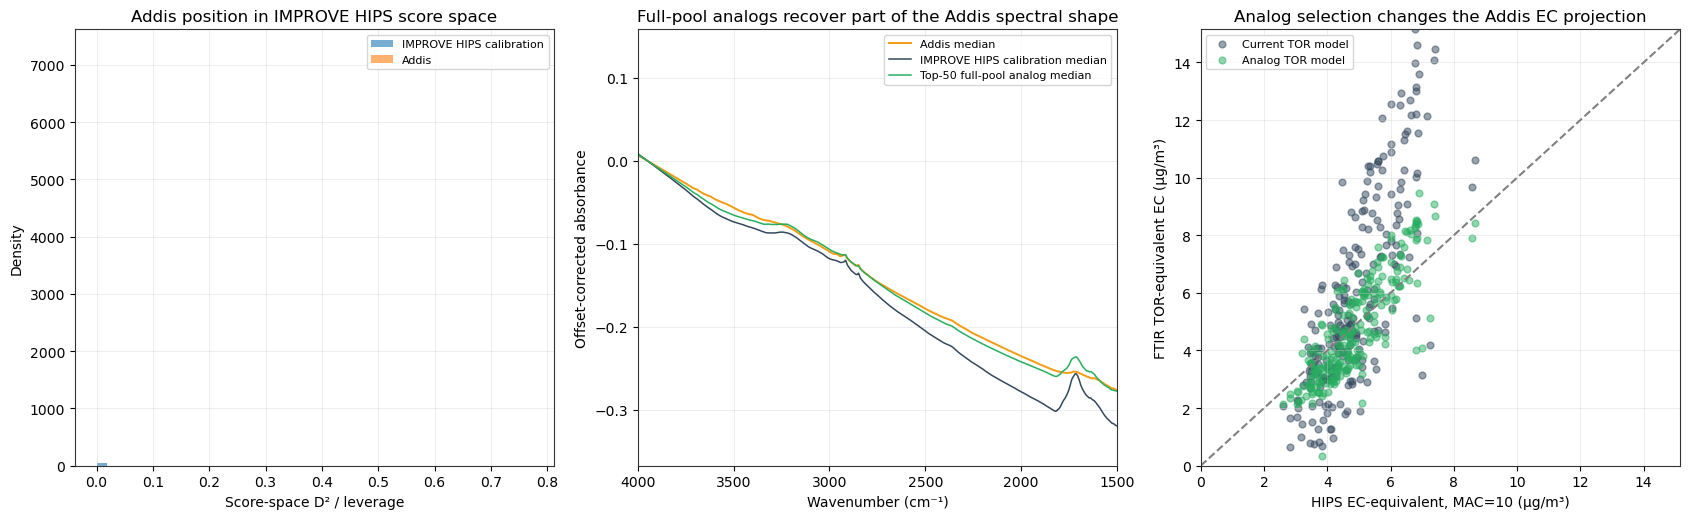

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.3))
axes[0].hist(mahalanobis_distance_squared(calibration_scores, inverse_score_ss),
             bins=40, density=True, alpha=0.6, label='IMPROVE HIPS calibration')
axes[0].hist(mahalanobis_distance_squared(etad_scores, inverse_score_ss),
             bins=40, density=True, alpha=0.6, label='Addis')
axes[0].set(xlabel='Score-space D² / leverage', ylabel='Density',
            title='Addis position in IMPROVE HIPS score space')
axes[0].legend(fontsize=8)

axes[1].plot(wn, addis_median, color=SITES['Addis_Ababa']['color'], lw=1.4,
             label='Addis median')
axes[1].plot(wn, improve_median, color='#34495E', lw=1.1,
             label='IMPROVE HIPS calibration median')
top_analog_ids = set(analogs.head(50)['AnalysisId'].astype(int))
top_analog_spectra = analog_training[analog_training['AnalysisId'].astype(int).isin(top_analog_ids)][wcols].to_numpy(float)
axes[1].plot(wn, np.nanmedian(offset_correct(top_analog_spectra, wn), axis=0),
             color='#27AE60', lw=1.1, label='Top-50 full-pool analog median')
axes[1].set_xlim(4000, 1500)
axes[1].set(xlabel='Wavenumber (cm⁻¹)', ylabel='Offset-corrected absorbance',
            title='Full-pool analogs recover part of the Addis spectral shape')
axes[1].legend(fontsize=8)

mac = 10.0
hips_ec = etad_eval['Fabs'].to_numpy(float) / mac
axes[2].scatter(hips_ec, etad_eval['EC_current_ugm3'], s=24, alpha=0.5,
                color='#34495E', label='Current TOR model')
axes[2].scatter(hips_ec, etad_eval['EC_analog_ugm3'], s=24, alpha=0.5,
                color='#27AE60', label='Analog TOR model')
hi = max(hips_ec.max(), etad_eval['EC_current_ugm3'].max(), etad_eval['EC_analog_ugm3'].max())
lo = min(0, etad_eval['EC_current_ugm3'].min(), etad_eval['EC_analog_ugm3'].min())
axes[2].plot([lo, hi], [lo, hi], '--', color='0.5')
axes[2].set(xlim=(lo, hi), ylim=(lo, hi), xlabel='HIPS EC-equivalent, MAC=10 (µg/m³)',
            ylabel='FTIR TOR-equivalent EC (µg/m³)',
            title='Analog selection changes the Addis EC projection')
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'full_pool_analog_selection_summary.png', dpi=180, bbox_inches='tight')
plt.show()

## Takeaways

- Searching the complete pool rather than smoke days alone finds a diverse analog cohort and yields
  a promising TOR recalibration at MAC = 10; the result is not robust enough to replace the deployed
  model because analog selection was informed by HIPS and evaluated against HIPS.
- Classical domain flags do not explain the transfer failure: Addis median score leverage and Q
  residual are close to the IMPROVE HIPS calibration. The robust HIPS model has only one component,
  so Q and VIP-weighted spectral mismatch remain essential complementary diagnostics.
- The strongest offset-corrected, HIPS-weighted gaps cluster near **1161, 1248, 1131, and 1463 cm⁻¹**.
  Treat these as search coordinates, not chemical identifications, until the full pool is processed
  with a validated AIRSpec EDF 6–8 workflow.
- The analog TOR CV optimum is **36 components** with a shallow neighborhood from roughly 33–37;
  component/VIP stability and a held-out TOR validation set are required next. The saved 400-sample
  list is ready for a preregistered R-tool rebuild and external test.